**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

**Load Dataset**

In [3]:
df=pd.read_excel('/content/Dataset for Data Analytics.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


**Shape**

In [4]:
df.shape

(1200, 14)

**Columns**

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

**Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

**Statistical Summary**

In [6]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


**Missing Values**

In [7]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


**Remove Duplicates**

In [8]:
df.drop_duplicates(inplace=True)

**Convert Date Column**

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

**Create New Features**

In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

**Drop Unnecessary Columns**

In [11]:
df.drop(['OrderID',
         'TrackingNumber'], axis=1, inplace=True)

**Target Variable Distribution**

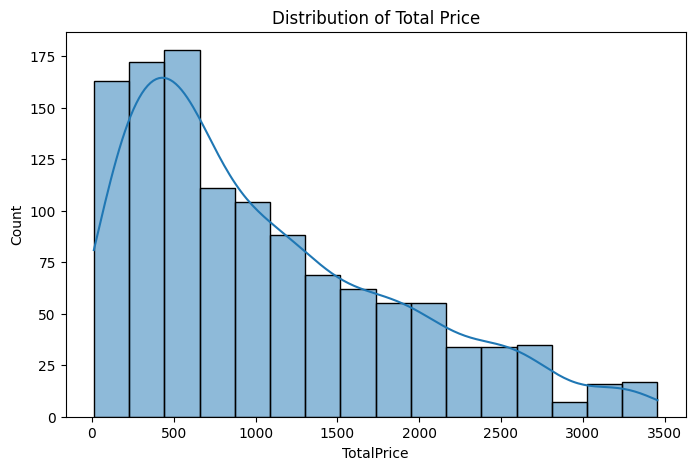

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPrice'], kde=True)
plt.title("Distribution of Total Price")
plt.show()

**Product Counts**

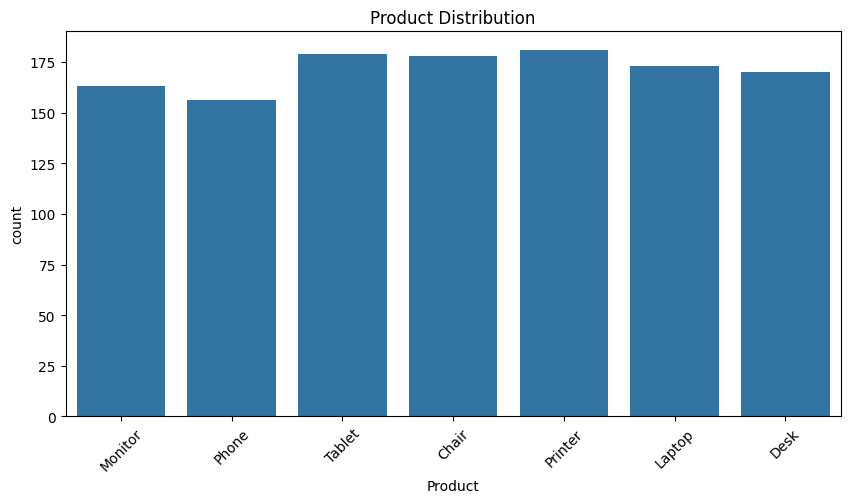

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(x='Product', data=df)
plt.xticks(rotation=45)
plt.title("Product Distribution")
plt.show()

**Payment Method Distribution**

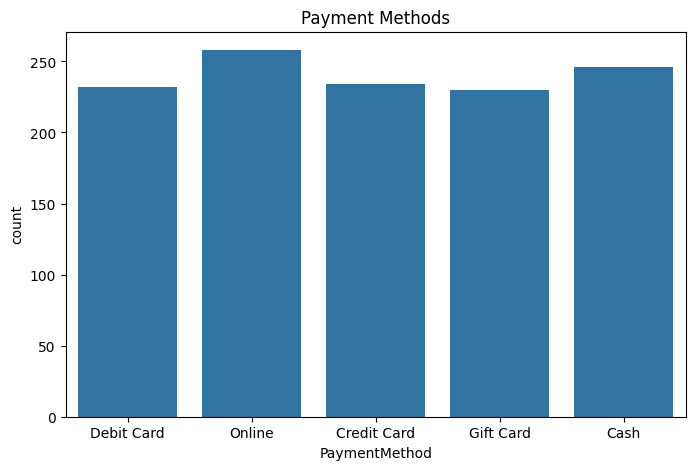

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', data=df)
plt.title("Payment Methods")
plt.show()

**Order Status Distribution**

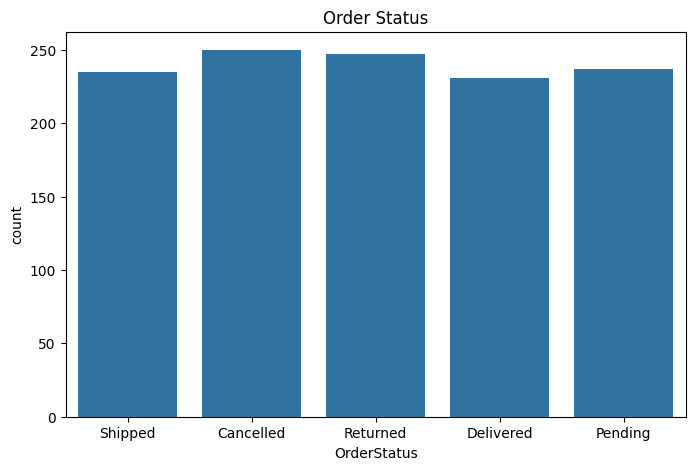

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='OrderStatus', data=df)
plt.title("Order Status")
plt.show()

**Referral Sources**

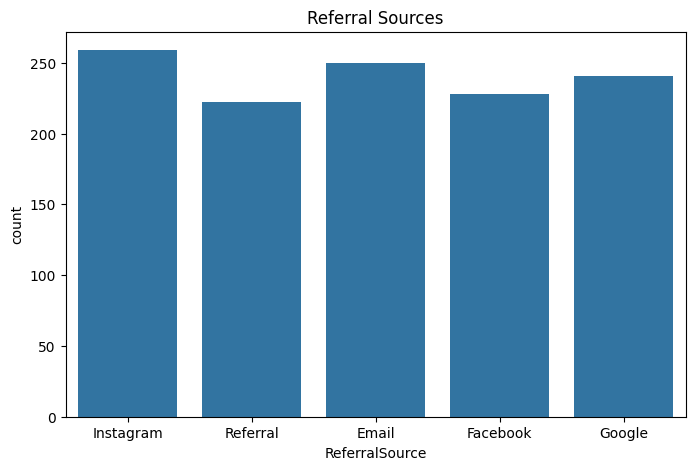

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='ReferralSource', data=df)
plt.title("Referral Sources")
plt.show()

**Monthly Sales Trend**

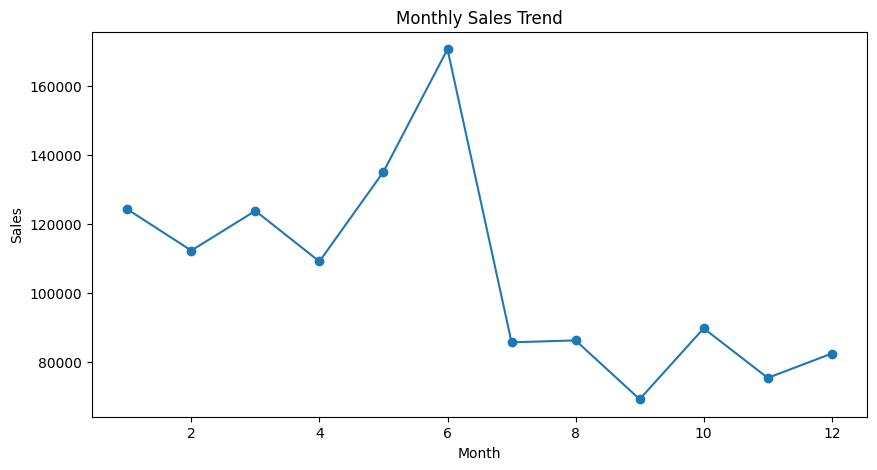

In [17]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

**Quantity vs Total Price**

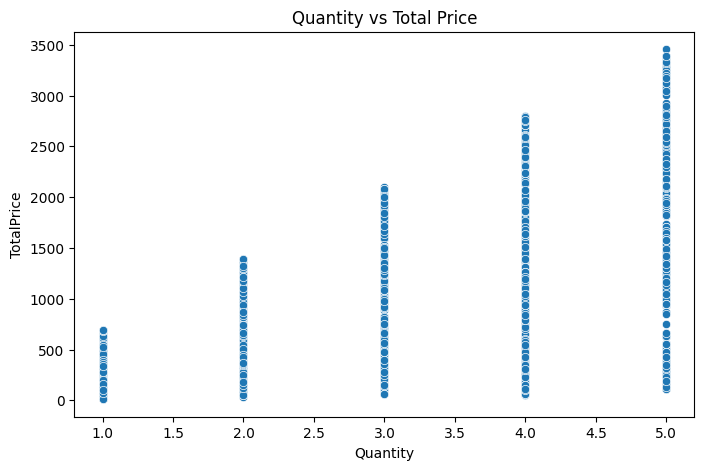

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity', y='TotalPrice', data=df)
plt.title("Quantity vs Total Price")
plt.show()

**Unit Price vs Total Price**


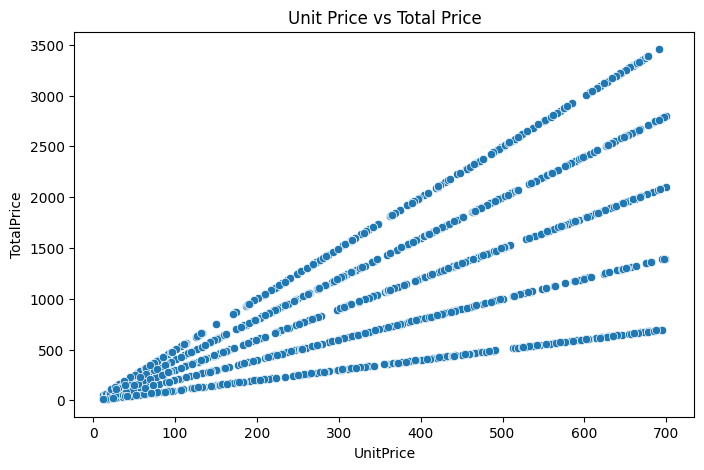

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='UnitPrice', y='TotalPrice', data=df)
plt.title("Unit Price vs Total Price")
plt.show()

**Correlation Heatmap**

In [20]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

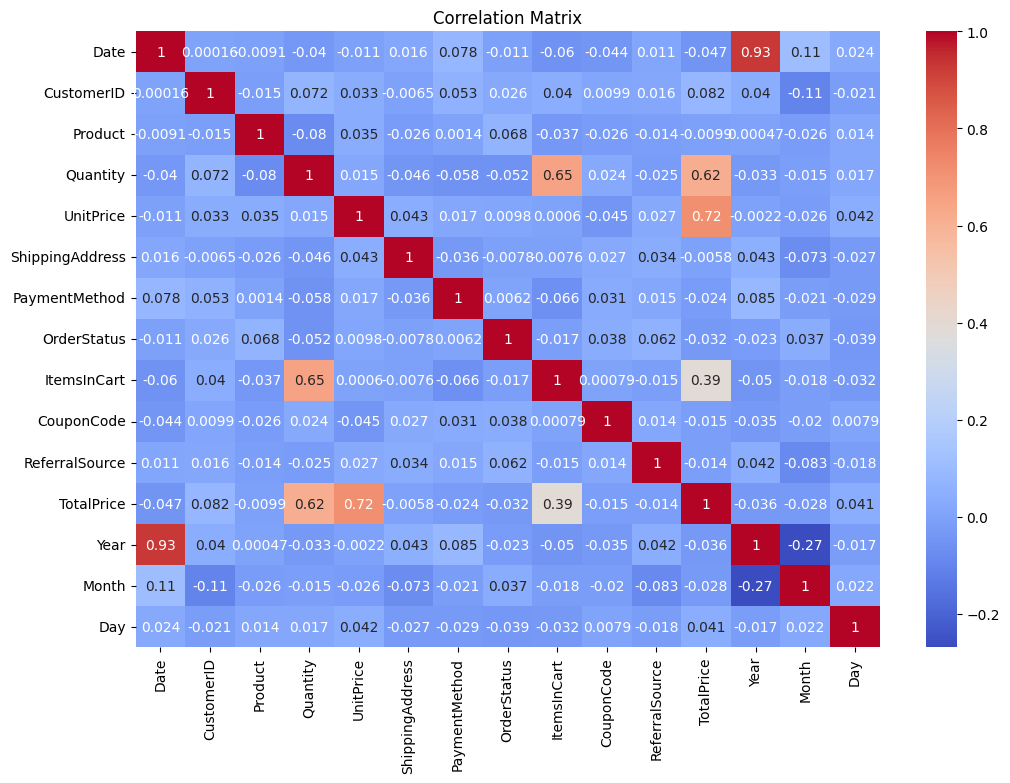

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

**Encode Categorical Features**

In [22]:
df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

After extracting numerical features from the 'Date' column, the original 'Date' column is no longer needed for modeling and can be dropped to prevent type errors during model training.

In [36]:
df_ml.drop('Date', axis=1, inplace=True)

**Define Features and Target**

In [40]:
X = df_ml.drop('TotalPrice', axis=1)
y = df_ml['TotalPrice']

**Train-Test Split**

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Linear Regression**

In [42]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")

print("MAE:", mean_absolute_error(y_test,y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print("R2 Score:", r2_score(y_test,y_pred_lr))

Linear Regression
MAE: 217.12405947174727
RMSE: 290.7503979295622
R2 Score: 0.8888898883200529


**Decision Tree**

In [44]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")

print("MAE:", mean_absolute_error(y_test,y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_dt)))
print("R2 Score:", r2_score(y_test,y_pred_dt))

Decision Tree
MAE: 18.36004166666665
RMSE: 30.52926143472848
R2 Score: 0.9987749733282031


**Random Forest Regressor**

In [45]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")

print("MAE:", mean_absolute_error(y_test,y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print("R2 Score:", r2_score(y_test,y_pred_rf))

Random Forest
MAE: 9.423927083333316
RMSE: 15.989780370639616
R2 Score: 0.9996639546072487


In [46]:
results = pd.DataFrame({
    'Model':['Linear Regression',
             'Decision Tree',
             'Random Forest'],

    'R2 Score':[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_dt),
        r2_score(y_test,y_pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.888890
1,Decision Tree,0.998775
2,Random Forest,0.999664


**Visualization of Model Comparison**

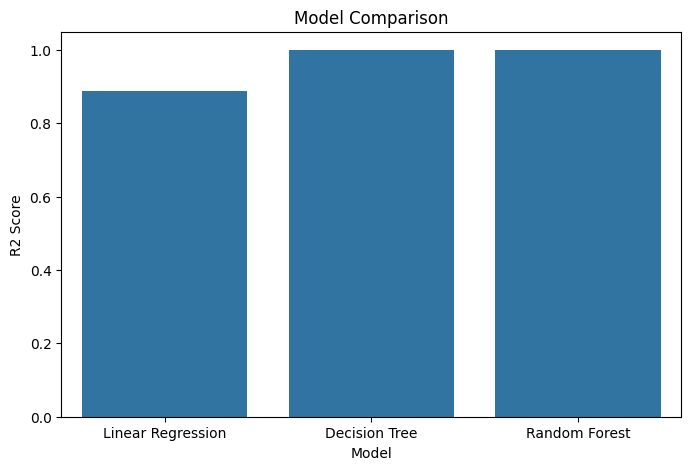

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")
plt.show()

**Feature Importance**

In [48]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
3,UnitPrice,0.532754
2,Quantity,0.466626
4,ShippingAddress,0.000091
0,CustomerID,0.000089
12,Day,0.000070
7,ItemsInCart,0.000063
6,OrderStatus,0.000057
11,Month,0.000056
1,Product,0.000054
8,CouponCode,0.000043


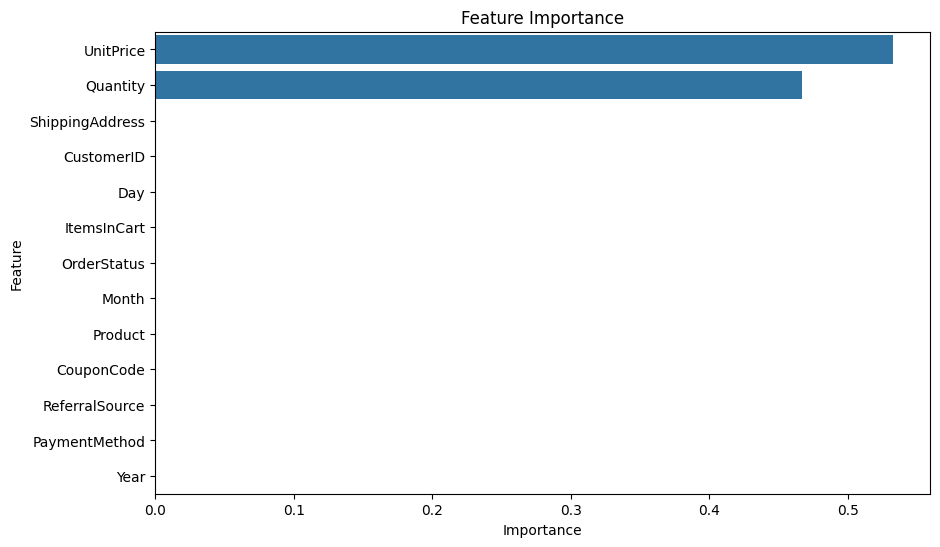

In [50]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()